In [3]:
# Used to plot examples for ground truth, and model outputs for visualization purposes
# Needs polishing

import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
import os
import models.unet_precip_regression_lightning as unet_regr
from models import SmaAT_UNet_VQ_lightning
from utils import dataset_precip

dataset = dataset_precip.precipitation_maps_oversampled_h5(
            in_file="data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5",
            num_input_images=12,
            num_output_images=6, train=False)

# 222, 444, 777, 1337 is fine
x, y_true = dataset[1337]

# add batch dimension
x = torch.tensor(x).unsqueeze(0)
y_true = torch.tensor(y_true).unsqueeze(0)
print(x.shape, y_true.shape)

models_dir = "lightning/precip_regression/comparison"
precip_models = [m for m in os.listdir(models_dir) if ".ckpt" in m]
print(precip_models)

# MSE loss here too for testing
loss_func = nn.MSELoss(reduction="sum")
print("Persistence", loss_func(x.squeeze()[-1]*47.83, y_true.squeeze()*47.83).item())

plot_images = dict()
for i, model_file in enumerate(precip_models):
    if "SmaAT_UNet_VQ_MSE" in model_file:
        model_name = "SmaAT_UNet_VQ_MSE"
        model = SmaAT_UNet_VQ_lightning.SmaAT_UNet_VQ
    elif "SmaAT_UNet_VQ_CE" in model_file:
        model_name = "SmaAT_UNet_VQ_CE"
        model = SmaAT_UNet_VQ_lightning.SmaAT_UNet_VQ
    elif "SmaAT_UNet_VQ_MWAE" in model_file:
        model_name = "SmaAT_UNet_VQ_MWAE"
        model = SmaAT_UNet_VQ_lightning.SmaAT_UNet_VQ
    elif "SmaAT_UNet" in model_file:
        model_name = "SmaAT_UNet"
        model = unet_regr.UNetDS_Attention
    elif "UNet" in model_file:
        model_name = "UNet"
        model = unet_regr.UNet
    else:
        raise NotImplementedError(f"Model not found")
    model = model.load_from_checkpoint(f"{models_dir}/{model_file}")

    model.to("cpu")
    model.eval()

    # Get prediction of model
    with torch.no_grad():
        y_pred = model(x)
        y_pred = y_pred[0]
    y_pred = y_pred.squeeze()
    print(model_name, loss_func(y_pred*47.83, y_true.squeeze()*47.83).item())

    plot_images[model_name] = y_pred

torch.Size([1, 12, 288, 288]) torch.Size([1, 288, 288])
['SmaAT_UNet_rain_threshold_50_epoch=80-val_total_loss=0.181938.ckpt', 'SmaAT_UNet_VQ_MSE-num32-commit0.75_rain_threshold_50_epoch=74-val_total_loss=0.183429.ckpt', 'SmaAT_UNet_VQ_MSE-MixConv-downdownmixmix-mixupupup-best-0.0120-num32-commit0.75_rain_threshold_50_epoch=49-val_total_loss=0.217658.ckpt']
Persistence 2703.911865234375


/home/nstavrou/.local/lib/python3.11/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.2.5, which is newer than your current Lightning version: v2.2.1


RuntimeError: Error(s) in loading state_dict for UNetDS_Attention:
	Missing key(s) in state_dict: "down3.maxpool_conv.1.mix1.0.layers.0.depthwise_conv.weight", "down3.maxpool_conv.1.mix1.0.layers.1.depthwise_conv.weight", "down3.maxpool_conv.1.mix1.1.weight", "down3.maxpool_conv.1.mix1.2.weight", "down3.maxpool_conv.1.mix1.2.bias", "down3.maxpool_conv.1.mix1.2.running_mean", "down3.maxpool_conv.1.mix1.2.running_var", "down3.maxpool_conv.1.mix2.0.layers.0.depthwise_conv.weight", "down3.maxpool_conv.1.mix2.0.layers.1.depthwise_conv.weight", "down3.maxpool_conv.1.mix2.1.weight", "down3.maxpool_conv.1.mix2.2.weight", "down3.maxpool_conv.1.mix2.2.bias", "down3.maxpool_conv.1.mix2.2.running_mean", "down3.maxpool_conv.1.mix2.2.running_var", "down4.maxpool_conv.1.mix1.0.layers.0.depthwise_conv.weight", "down4.maxpool_conv.1.mix1.0.layers.1.depthwise_conv.weight", "down4.maxpool_conv.1.mix1.1.weight", "down4.maxpool_conv.1.mix1.2.weight", "down4.maxpool_conv.1.mix1.2.bias", "down4.maxpool_conv.

In [1]:
#### Plotting ####
# Plots them in a single column
plt.figure(figsize=(10, 20))
plt.subplot(len(precip_models)+2, 1, 1)
plt.imshow(y_true.squeeze()*47.83)
plt.colorbar()
plt.title("Ground truth")
plt.axis("off")

# plt.subplot(len(precip_models)+2, 1, 2)
# plt.imshow(x.squeeze()[-1]*47.83, vmax=torch.max(y_true*47.83), vmin=torch.min(y_true*47.83))
# plt.colorbar()
# plt.title("Persistence")
# plt.axis("off")

for i, (model_name, y_pred) in enumerate(plot_images.items()):
    print(model_name)
    plt.subplot(len(precip_models)+2, 1, i+3)
    plt.imshow(y_pred*47.83, vmax=torch.max(y_true*47.83), vmin=torch.min(y_true*47.83))
    plt.colorbar()
    plt.title(model_name)
    plt.axis("off")
# plt.colorbar()
plt.show()

NameError: name 'plt' is not defined

SmaAT_UNet_VQ_MWAE


IndexError: index 2 is out of bounds for axis 0 with size 2

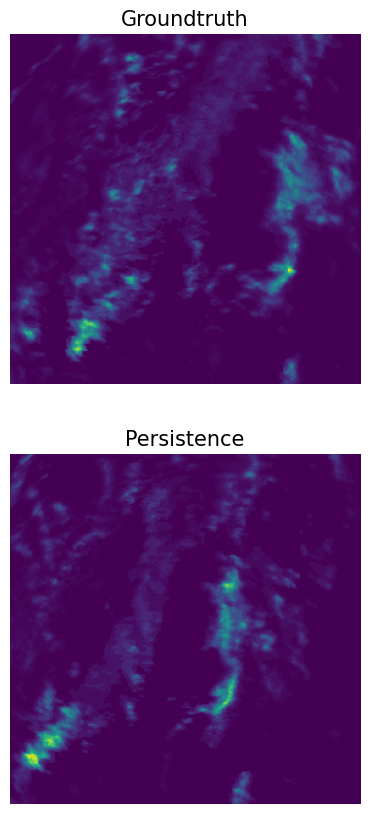

In [6]:
# Plotting
# Plots them in 2 columns but I think it needs 4 plots at least

fig, axesgrid = plt.subplots(nrows=2, ncols=(len(precip_models)+2)//2, figsize=(20, 10))
axes = axesgrid.flat
im = axes[0].imshow(y_true.squeeze()*47.83)
axes[0].set_title("Groundtruth", fontsize=15)
axes[0].set_axis_off()
axes[1].imshow(x.squeeze()[-1]*47.83, vmax=torch.max(y_true*47.83), vmin=torch.min(y_true*47.83))
axes[1].set_title("Persistence", fontsize=15)
axes[1].set_axis_off()

# for ax in axes.flat[2:]:
for i, (model_name, y_pred) in enumerate(plot_images.items()):
    print(model_name)
#     plt.subplot(len(precip_models)+2, 1, i+3)
    axes[i+2].imshow(y_pred*47.83, vmax=torch.max(y_true*47.83), vmin=torch.min(y_true*47.83))
    axes[i+2].set_title(model_name, fontsize=15)
    axes[i+2].set_axis_off()
#     im = ax.imshow(np.random.random((16, 16)), cmap='viridis',
#                    vmin=0, vmax=1)

fig.subplots_adjust(wspace=0.02)
cbar = fig.colorbar(im, ax=axesgrid.ravel().tolist(), shrink=1)
cbar.ax.set_ylabel('mm/5min', fontsize=15)
plt.savefig("plots/Precip_example.eps")
plt.savefig("plots/Precip_example.png", dpi=300)
plt.show()